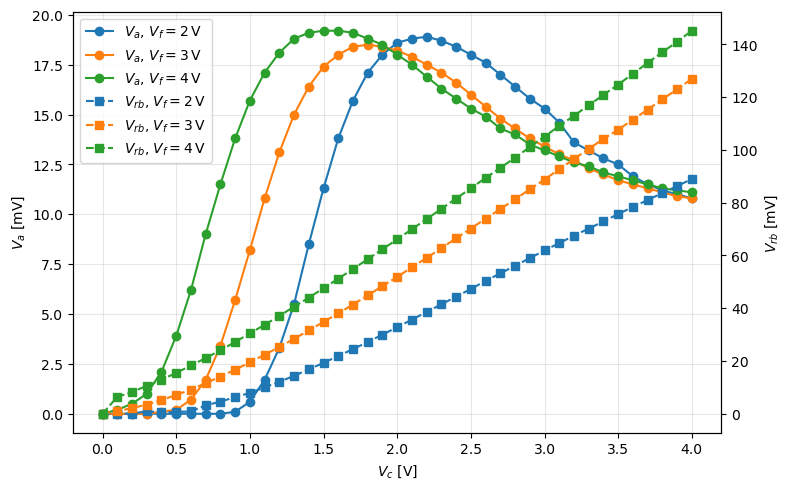

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datos/datos_ram_limpio.csv")

df = df.sort_values(["V_filamento_V", "Vc_V"])

colores = {
    2.0: "tab:blue",
    3.0: "tab:orange",
    4.0: "tab:green",
}

fig, ax1 = plt.subplots(figsize=(8, 5))

ax2 = ax1.twinx()

for vf in sorted(df["V_filamento_V"].unique()):
    datos = df[df["V_filamento_V"] == vf]

    color = colores.get(vf, None)

    ax1.plot(
        datos["Vc_V"],
        datos["Va_mV"],
        marker="o",
        linestyle="-",
        color=color,
        label=rf"$V_a$, $V_f={vf:g}\,\mathrm{{V}}$"
    )

    ax2.plot(
        datos["Vc_V"],
        datos["Vrb_mV"],
        marker="s",
        linestyle="--",
        color=color,
        label=rf"$V_{{rb}}$, $V_f={vf:g}\,\mathrm{{V}}$"
    )

ax1.set_xlabel(r"$V_c$ [V]")
ax1.set_ylabel(r"$V_a$ [mV]")
ax2.set_ylabel(r"$V_{rb}$ [mV]")

ax1.grid(True, alpha=0.3)

lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()

ax1.legend(
    lineas1 + lineas2,
    etiquetas1 + etiquetas2,
    loc="best"
)

#plt.title(r"$V_a$ y $V_{rb}$ contra $V_c$ para distintos voltajes de filamento")

fig.tight_layout()

plt.savefig("va_vrb_vs_vc_una_grafica.png", dpi=300, bbox_inches="tight")

plt.show()